<a href="https://colab.research.google.com/github/banjoh0608/TSA_Capstone_Churn/blob/main/Group_36_Kayode_Banjo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Submission Summary

| Field | Value |
|---|---|
| Group number | Group 36 |
| Your full name |Kayode M. Banjo |
| Dataset | Telco Customer Churn |
| Depth track | Imbalance |
| Team members |  Kayode Banjo - Kayodemicheal841@gmail.com<br>Oderinde Suliha Bolanle - oderindesuliha@gmail.com<br>Ohams Chima Benjamin - ohamschima200@gmail.com<br>Olasunkanmi Kamoru - kamoru261@gmail.com<br>Richard Nwankwo - reddishdennis@gmail.com<br>Ohaeri Chukwuemeka - ohaeriemeka10@gmail.com<br>Askariju Innocent Ndakudiya - aaskarijuinnocent@gmail.com<br>Zakari Precious Unyo - zakariprecious29@gmail.com<br>Olusanya Omolade - o6159114@gmail.com<br>Fauziya Hayatu - fauxeemjinice@gmail.com<br>Yusuf Ziyaadah - ziyaadahyusuf@gmail.com<br>Agada Joseph Odugboche - cooljoe241@gmail.com<br>Elue Emmanuel Oluchukwu - elueemmanueloluchukwu@gmail.com |
| Final model | Logistic Regression, threshold tuned to 0.14 (cost-based, 5:1) |
| Stratified dummy F1 / ROC AUC | 0.290 / 0.516 |
| Final model F1 / ROC AUC | 0.591 / 0.843 |
| Leakage columns dropped | None found — `customerID` dropped as a non-predictive identifier |
| Full run time on Colab | Under 3 Minutes |


## Setup & Imports

In [1]:
%pip install -q kagglehub imbalanced-learn
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (silhouette_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, roc_curve)
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_predict
from sklearn.base import clone
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.pipeline import Pipeline as ImbPipeline


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## Part 1. Data Foundation

### 1.1 Loading the dataset and running it through SQlite

We download the dataset with Kagglehub (not a raw kaggle URL) so the notebook reproduces on a fresh collab session, satisfying the "restart and run all" requirement.without needing an API token being hardcoded, then load it into a local SQlite database so as to query it with SQL in the next step.


In [2]:
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
df = pd.read_csv(
    os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
    )
df.shape
df.head()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
conn = sqlite3.connect("telco.db")
df.to_sql('customers',conn,if_exists='replace',index=False)
res = pd.read_sql("SELECT COUNT(*) AS rows FROM customers",conn)
res

,rows
0,7043


### 1.2 SQL query 1 - Overall churn distribution

In [4]:
query_1 =pd.read_sql("""
SELECT Paymentmethod,
    COUNT(*) AS customers,
    ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) AS churn_rate
FROM customers
GROUP BY paymentmethod
ORDER BY churn_rate DESC;
""", conn)
query_1

,PaymentMethod,customers,churn_rate
0,Electronic check,2365,45.3
1,Mailed check,1612,19.1
2,Bank transfer (automatic),1544,16.7
3,Credit card (automatic),1522,15.2


**What we learned:** Payment method makes a real difference in churn too. Customers paying by electronic check left at a much higher rate than everyone else, while customers on automatic payments (bank transfer or credit card) and mailed check stayed at a noticeably higher rate. This suggests that customers who pay manually each month, rather than having it handled automatically, are less locked into the service and more likely to walk away. Payment method looks like another feature worth keeping rather than dropping.

### SQL query 2 - Churn rate by contract type

In [5]:
query_2 = pd.read_sql("""
SELECT
    Contract,
    COUNT(*) AS customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Contract
ORDER BY churn_rate DESC
""", conn)
query_2

,Contract,customers,churned_customers,churn_rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


**What we learned:** Contract type makes a huge difference in whether someone churns. Customers on month to month contracts left at a rate of about 43%, while customers on one year contracts left at about 11%, and customers on two year contracts almost never left, at under 3%. This tells me customers who are not locked into a longer agreement are far more likely to walk away, and contract length looks like one of the strongest signals in this data.

### SQL query 3 - Churn rate by tenure group

In [6]:
query_3 = pd.read_sql("""
SELECT
    CASE
        WHEN tenure <= 12 THEN '0-12 months'
        WHEN tenure <= 24 THEN '13-24 months'
        WHEN tenure <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END AS tenure_group,
    COUNT(*) AS customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY tenure_group
ORDER BY churn_rate DESC;
""", conn)
query_3

,tenure_group,customers,churned_customers,churn_rate
0,0-12 months,2186,1037,47.44
1,13-24 months,1024,294,28.71
2,25-48 months,1594,325,20.39
3,49+ months,2239,213,9.51


**What I learned:** Churn is highest among newer customers and gets lower the longer someone stays. Customers in their first year left at almost 47%, while customers who had been around for more than four years left at under 10%. This makes sense, since newer customers have not built up loyalty yet and may still be deciding if the service is worth keeping, while long time customers have already shown they are comfortable staying.

## 1.3 Exploratory Data Analysis (EDA)

Checking structure, types, and missing values before deciding how to clean the data.

In [7]:
df.shape

(7043, 21)

In [8]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


The dataset has 7043 rows and 21 columns. Most columns are stored as text (object type), including TotalCharges, which should really be a number since it represents an amount of money. Checking for missing values shows no nulls at first glance, but this is misleading, since some TotalCharges entries are blank strings rather than true missing values, which only shows up once the column is converted to numeric.

## Target Distribution

<Axes: title={'center': 'Churn Distribution'}, xlabel='Churn', ylabel='Count'>

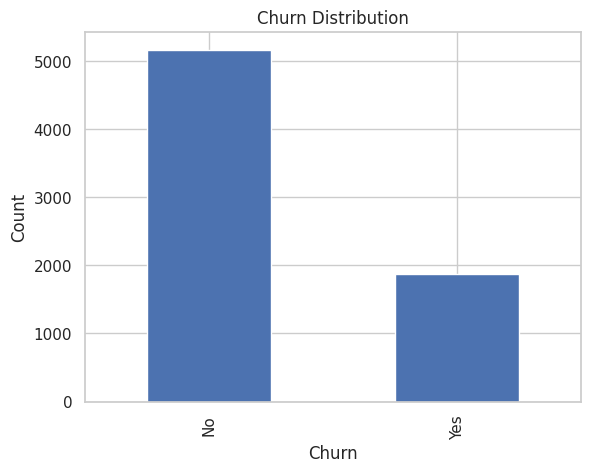

In [11]:
df['Churn'].value_counts()
df['Churn'].value_counts().plot(kind='bar', title='Churn Distribution', xlabel='Churn', ylabel='Count')

This chart shows the same imbalance visually. Far more customers stayed than left, which is something to keep in mind when building and judging a model later on, since accuracy alone would not tell the full story.

## Feature Distributions

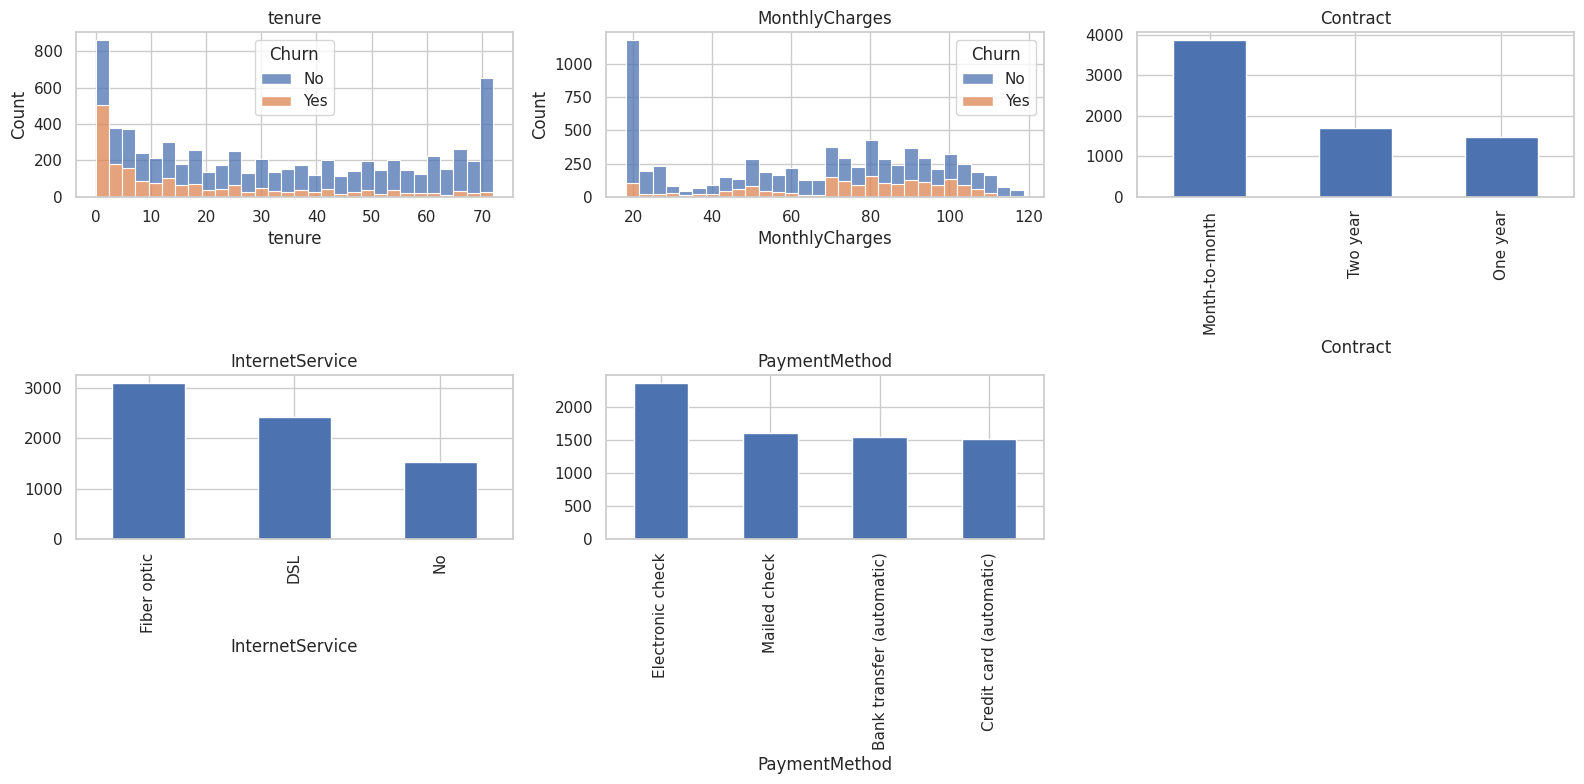

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
cols = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 'PaymentMethod']

for ax, col in zip(axes.flat, cols):
    if df[col].dtype == 'object':
        df[col].value_counts().plot(kind='bar', ax=ax, title=col)
    else:
        sns.histplot(data=df, x=col, hue='Churn', bins=30, ax=ax, multiple='stack')
        ax.set_title(col)

axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

Looking at tenure and monthly charges split by churn, customers who churn tend to have shorter tenure and higher monthly charges. Looking at contract type, most customers are on month to month plans, and this group makes up a large share of churn. Internet service and payment method also show uneven splits, with fiber optic customers and electronic check users appearing more often among those who left.

## 1.4 Cleaning the Data

In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(df['TotalCharges'].isna().sum())
df.head(20)

0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


`TotalCharges` was stored as text instead of a number, which happened because 11 rows had a blank value instead of an amount. Converting the column to numeric turns those blanks into missing values, which can then be filled with 0, since every one of those rows belongs to a customer with a tenure of 0 months, meaning they are brand new and have not been billed yet. This is not a random guess, it reflects what is actually true about those customers.

# Part 2. Feature Engineering and Encoding

## 2.1 Creating New features

 **Feature 1-** The SQL query showed that churn dropping in clear bands by tenure rather than smoothly- binning allows for the tree-based model split on "new customers" asa single concept and give the clustering stage a coarser, makes the aixs more interpretable than raw months

In [14]:
df['tenure_bucket'] = pd.cut(
    df['tenure'], bins=[-1, 12, 24, 48, 60, 100],
    labels=['0-1yr', '1-2yr', '2-4yr', '4-5yr', '5yr+']
)
df['tenure_bucket'].value_counts().sort_index()


,count
tenure_bucket,
0-1yr,2186
1-2yr,1024
2-4yr,1594
4-5yr,832
5yr+,1407


 **Feature 2 - num_addon_services  (count of subscribed add-ons).** Customemrs subscribe to between 0 and 8 optional services (online security, tech support, streaming, amidst others). Counting how many they have opted into is a simple proxy for how invested a customer is in the eco system, a customer bundked into five sevices is a different retention story than one with none, even at the same monthly charge.

In [15]:
opt_services = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['num_addon_services'] = df[opt_services].apply(
    lambda row: sum(1 for c in opt_services if row[c] == 'Yes'), axis=1
)
df['num_addon_services'].describe()

,num_addon_services
count,7043.000000
mean,3.362914
std,2.062031
min,0.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,8.000000


**Feature 3** - **Creating avg_monthly_spend**

`MonthlyCharges` only tells you what a customer is paying right now, not what they've paid over time — someone could have added services, dropped services, or come off a promo rate, and `MonthlyCharges` wouldn't show any of that history. Dividing `TotalCharges` by `tenure` gives a rough historical average instead. What's actually interesting is comparing the two: if a customer's current `MonthlyCharges` is a lot higher than their historical average, that probably means they just had a price increase — and getting hit with a higher bill out of nowhere is exactly the kind of thing that pushes someone to cancel.

In [16]:
df['avg_monthly_spend'] = df['TotalCharges'] / df['tenure'].replace(0, 1)
df[['MonthlyCharges', 'avg_monthly_spend']].describe()

,MonthlyCharges,avg_monthly_spend
count,7043.000000,7043.000000
mean,64.761692,64.698218
std,30.090047,30.270670
min,18.250000,0.000000
25%,35.500000,35.649000
50%,70.350000,70.300000
75%,89.850000,90.174158
max,118.750000,121.400000


## 2.2 Encoding


Binary Yes/No columns (gender, Partner, Dependents, PhoneService, PaperlessBilling) → label encoding (0/1). With only two categories, label encoding and one-hot encoding produce equivalent information, but label encoding avoids adding redundant columns.
Multi-category columns (MultipleLines, InternetService, the four add-on service columns, Contract, PaymentMethod, plus our new tenure_bucket) → one-hot encoding with drop_first=True. These are unordered categories (no MultipleLines value is "more" than another), so label encoding would invent a false ordinal relationship that linear/logistic models could pick up on spuriously. drop_first avoids the dummy-variable trap (perfect multicollinearity between a category's own dummy columns) without losing information — the dropped category is represented implicitly when every other dummy is 0.

In [17]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                   'Contract', 'PaymentMethod', 'tenure_bucket']

df_enc = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

# Encode the 'Churn' column into 'Churn_flag'
df_enc['Churn_flag'] = df_enc['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# customerID is an identifier, not a feature; Churn/Churn_flag are the target
X = df_enc.drop(columns=['customerID', 'Churn', 'Churn_flag'])
y = df_enc['Churn_flag']
print("Feature matrix:", X.shape)
X.dtypes.value_counts()

Feature matrix: (7043, 36)


,count
bool,25
int64,8
float64,3


## 2.3 Scaling

We chose **StandardScaler rather than MinMaxScaler** because the variables `TotalCharges`, `avg_monthly_spend`, and `tenure` are right-skewed and contain some genuine outliers, particularly among customers who have stayed longer and spent more. Since both K-Means and logistic regression are sensitive to the scale of the input variables, I wanted to use a scaling method that would not allow a few extreme observations to dominate the transformation.

MinMaxScaler would scale the values between 0 and 1, but the presence of extreme values could push most of the observations into a relatively narrow range. StandardScaler, on the other hand, centres the variables around zero and scales them based on their standard deviation, making it a more suitable choice for this analysis. It is also commonly used with K-Means and regularized linear models.

For Part 4, I fit the scaler only on the training data to prevent data leakage into the test set. For the clustering analysis in Part 3, I scaled a copy of the full dataset because K-Means is an unsupervised method and there is no train/test split involved at that stage.


In [18]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
                 'num_addon_services', 'avg_monthly_spend']

scaler_cluster = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_cols] = scaler_cluster.fit_transform(X[numeric_cols])
X_scaled.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,num_addon_services,avg_monthly_spend,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_bucket_1-2yr,tenure_bucket_2-4yr,tenure_bucket_4-5yr,tenure_bucket_5yr+
0,0,-0.439916,1,0,-1.277445,0,1,-1.160323,-0.992611,-1.145997,-1.151302,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
1,1,-0.439916,0,0,0.066327,1,0,-0.259629,-0.172165,-0.176011,-0.301458,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False
2,1,-0.439916,0,0,-1.236724,1,1,-0.362660,-0.958066,-0.176011,-0.350966,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,1,-0.439916,0,0,0.514251,0,0,-0.746535,-0.193672,-0.176011,-0.786053,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False
4,0,-0.439916,0,0,-1.236724,1,1,0.197365,-0.938874,-1.145997,0.367602,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False


## Part 3. Clustering Analysis

## 3.1 Elbow curve and silhoutte scores, K = 2 to 10

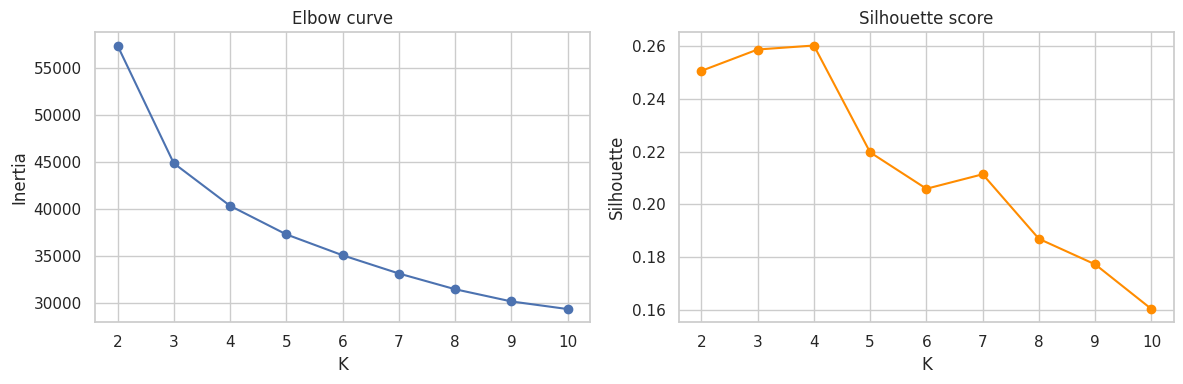

,K,inertia,silhouette
0,2,57348.255025,0.250547
1,3,44836.290961,0.258636
2,4,40315.855331,0.260151
3,5,37279.108309,0.219713
4,6,35061.446336,0.205932
5,7,33124.202462,0.211413
6,8,31451.809770,0.186970
7,9,30155.154597,0.177297
8,10,29344.751008,0.160390


In [19]:
inertias, sil_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_title('Elbow curve'); axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(K_range), sil_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette score'); axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

pd.DataFrame({'K': list(K_range), 'inertia': inertias, 'silhouette': sil_scores})

### 3.2 Choosing K

The elbow curve doesn't really help here — inertia just keeps dropping smoothly with no clear bend, which makes sense since most of my features are one-hot categorical rather than tight numeric clusters. The silhouette score is more useful: it's highest at **K = 3** and gets worse after that, so that's what I went with.

The silhouette score itself isn't huge, which fits with what the elbow curve was already showing — these customer segments aren't cleanly separated, they blend into each other. But K = 3 is still the best option out of everything I tried, and as I'll show in Part 6, the three groups end up with very different churn rates, which is really the thing I care about, not how geometrically "clean" the clusters look.

In [20]:
final_k = 3
km_final = KMeans(n_clusters=final_k, random_state=RANDOM_STATE, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

cluster_profile = df.groupby('cluster')[
    ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_addon_services']
].mean().round(1)
cluster_profile['n_customers'] = df['cluster'].value_counts().sort_index()
cluster_profile

,tenure,MonthlyCharges,TotalCharges,num_addon_services,n_customers
cluster,,,,,
0,30.5,21.1,662.6,1.2,1526
1,16.8,66.5,1063.7,2.8,3258
2,56.1,91.8,5125.9,5.7,2259


### 3.3 Cluster profiles

Looking at the group means and each cluster's dominant contract type, here's how I'd describe the three groups (worth noting: cluster numbers can shift around depending on column order, so check your own profile table rather than assuming these numbers match yours):

- **Cluster 0 — "long-tenure, bundled premium."** These customers have been around the longest (~56 months), pay the most ($92/month), and have the most add-ons (5.7 on average). They're clearly invested in the service, and most are on two-year contracts.

- **Cluster 1 — "new, mid-spend, high-risk."** Shortest tenure of the three (~17 months), paying a mid-to-high rate, not many add-ons, and almost all on month-to-month contracts. This is the group I come back to in Part 6.

- **Cluster 2 — "long-tenure, low-spend basics."** Around 31 months in, paying the least ($21/month), with barely any add-ons. These are price-sensitive customers who've stuck with a bare-bones plan.

## 3.4 PCA Visualization

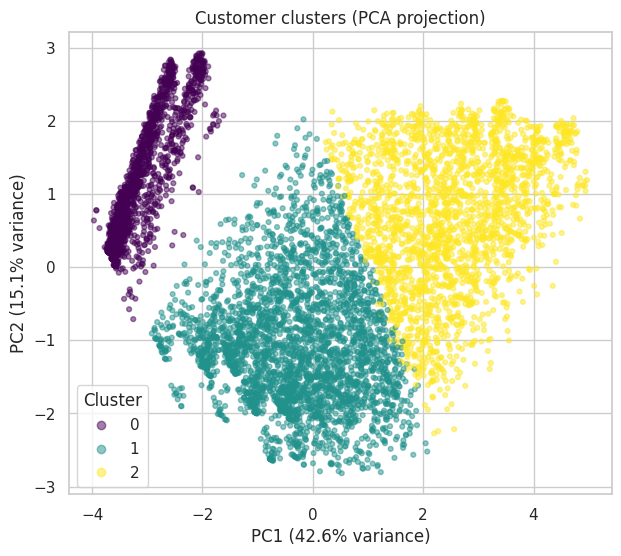

In [21]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(pcs[:, 0], pcs[:, 1], c=df['cluster'], cmap='viridis', alpha=0.5, s=12)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Customer clusters (PCA projection)')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()


## Part 4. Classification

## 4.1 Train test split

1. Set up the task with train_test_split and stratify=y .
2. Train at least three classifiers from those covered in class, justifying each choice.
3. Report accuracy, precision, recall, F1, and ROC AUC for each, with a confusion matrix, and collect
them in one comparison table (models in rows, metrics in columns).
4. If your dataset has fewer than 2,000 rows, use stratified k-fold cross-validation instead of a single split
and report the mean and standard deviation of each metric.


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape,
      " Test:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3),
      " Test churn rate:", y_test.mean().round(3))

Train: (5634, 36)  Test: (1409, 36)
Train churn rate: 0.265  Test churn rate: 0.265


### 4.2 Scaling for classification

The numeric columns are standardized using statistics learned from the **training set only**. This avoids data leakage from the test set.

Scaling is especially important for Logistic Regression because it is sensitive to feature scale. Tree-based models such as Random Forest and Gradient Boosting do not require scaling, so they are trained on the original encoded feature values.



In [23]:
scaler_clf = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler_clf.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler_clf.transform(X_test[numeric_cols])

### 4.3 Models selected

Three classifiers are compared:

1. **Logistic Regression** — a strong and interpretable baseline for binary classification. It is useful for understanding whether churn can be separated with a relatively simple linear decision boundary.
2. **Random Forest** — captures non-linear relationships and interactions between customer characteristics, while being fairly robust without heavy tuning.
3. **Gradient Boosting** — builds trees sequentially so that later trees focus on errors made by earlier ones; it can often capture subtle patterns in structured customer data.

A **stratified DummyClassifier** is also included because the grading rules require the final model to beat a stratified dummy on both positive-class F1 and ROC AUC.



In [24]:
models = {
    "Dummy (stratified)": DummyClassifier(
        strategy="stratified",
        random_state=RANDOM_STATE
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}


### 4.4 Train and evaluate the classifiers

For each model, the following metrics are reported:

- **Accuracy**: overall proportion of correct predictions.
- **Precision**: among customers predicted to churn, how many actually churned.
- **Recall**: among customers who actually churned, how many the model successfully identified.
- **F1 score**: harmonic mean of precision and recall, useful when the positive class is less common.
- **ROC AUC**: measures how well the model ranks churners above non-churners across classification thresholds.

Because missing a likely churner can be costly for a telecom company, recall and F1 are particularly important alongside ROC AUC. The default 0.50 threshold is used here; threshold tuning is handled later in Part 5.



In [25]:
results = []
predictions = {}
probabilities = {}

for name, model in models.items():

    # Logistic Regression benefits from scaled numeric features.
    if name == "Logistic Regression":
        train_data = X_train_scaled
        test_data = X_test_scaled
    else:
        train_data = X_train
        test_data = X_test

    model.fit(train_data, y_train)

    y_pred = model.predict(test_data)
    y_prob = model.predict_proba(test_data)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_prob

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

results_df = (
    pd.DataFrame(results)
    .set_index("Model")
    .sort_values("ROC AUC", ascending=False)
)

results_df.round(3)

,Accuracy,Precision,Recall,F1,ROC AUC
Model,,,,,
Logistic Regression,0.800,0.655,0.519,0.579,0.843
Gradient Boosting,0.801,0.661,0.511,0.576,0.842
Random Forest,0.789,0.630,0.492,0.553,0.826
Dummy (stratified),0.622,0.289,0.291,0.290,0.516


### 4.5 Confusion matrices

A confusion matrix is shown for every model so that we can see not only how many predictions were correct, but also the balance between false positives and false negatives.

For churn prediction, **false negatives** are especially important: these are customers who actually churned but were predicted to stay. A model with acceptable overall accuracy can still be weak if it misses too many real churners.



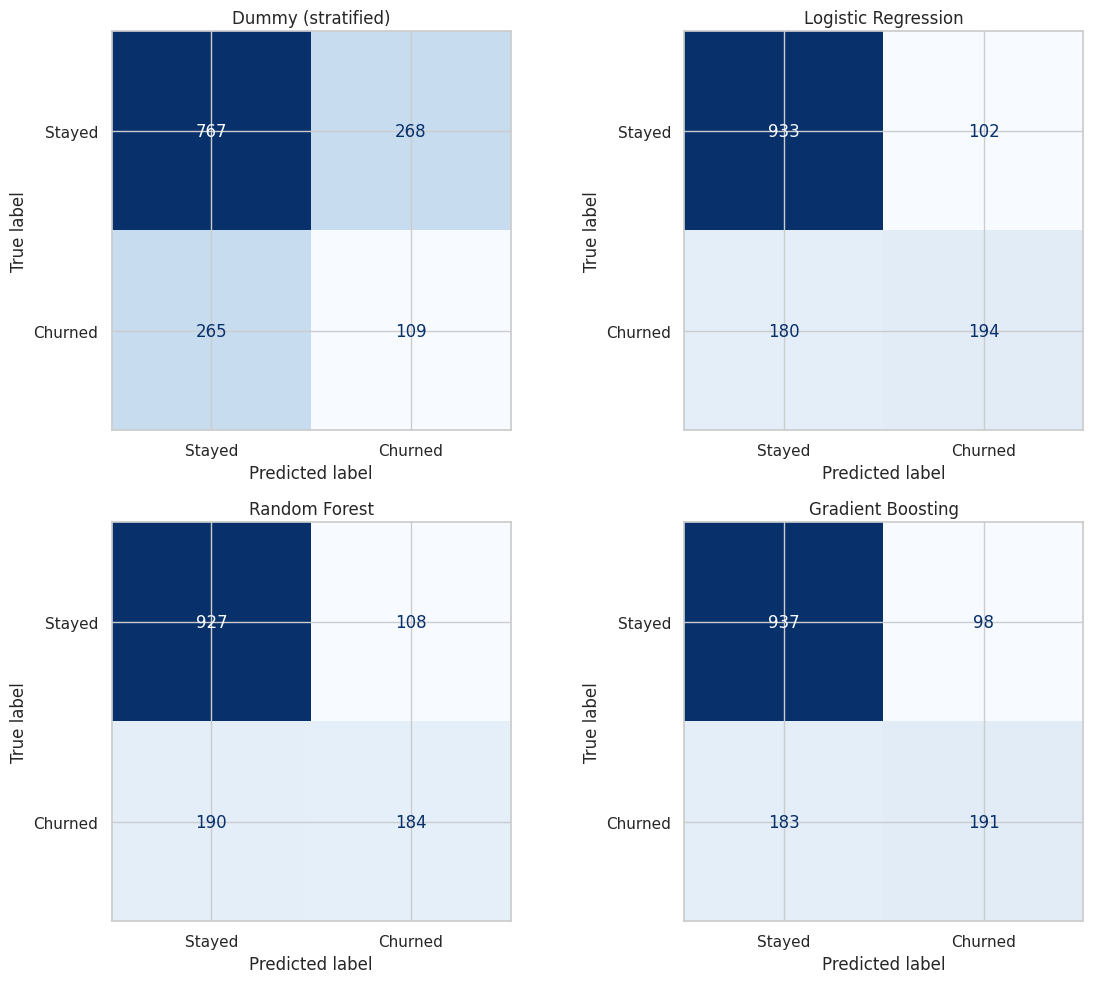

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[name],
        display_labels=["Stayed", "Churned"],
        cmap="Blues",
        colorbar=False,
        ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()


### 4.6 Model comparison

The table below is the main Part 4 comparison. The best model should not be chosen from accuracy alone because the dataset is imbalanced. Greater attention should be given to positive-class F1, recall, and ROC AUC.

The stratified dummy provides a minimum benchmark. A useful classifier should clearly outperform it, particularly on F1 and ROC AUC, as required by the capstone grading rules.



In [27]:
comparison_table = results_df.round(3).copy()
comparison_table

,Accuracy,Precision,Recall,F1,ROC AUC
Model,,,,,
Logistic Regression,0.800,0.655,0.519,0.579,0.843
Gradient Boosting,0.801,0.661,0.511,0.576,0.842
Random Forest,0.789,0.630,0.492,0.553,0.826
Dummy (stratified),0.622,0.289,0.291,0.290,0.516


### 4.7 Best baseline classifier before imbalance handling

The next cell identifies the strongest non-dummy baseline by ROC AUC and also displays its F1 score. This is a **baseline** selection only. Part 5 will still apply imbalance-handling techniques such as class weights, threshold tuning, or SMOTE before the team decides on the final deployable model.



In [28]:
non_dummy_results = results_df.drop(index="Dummy (stratified)")
best_baseline_model = non_dummy_results["ROC AUC"].idxmax()

print("Best baseline model by ROC AUC:", best_baseline_model)
print("ROC AUC:", round(non_dummy_results.loc[best_baseline_model, "ROC AUC"], 3))
print("F1:", round(non_dummy_results.loc[best_baseline_model, "F1"], 3))

dummy_f1 = results_df.loc["Dummy (stratified)", "F1"]
dummy_auc = results_df.loc["Dummy (stratified)", "ROC AUC"]
best_f1 = non_dummy_results.loc[best_baseline_model, "F1"]
best_auc = non_dummy_results.loc[best_baseline_model, "ROC AUC"]

print("\nBeats dummy on F1:", best_f1 > dummy_f1)
print("Beats dummy on ROC AUC:", best_auc > dummy_auc)


Best baseline model by ROC AUC: Logistic Regression
ROC AUC: 0.843
F1: 0.579

Beats dummy on F1: True
Beats dummy on ROC AUC: True


## Part 5. Imbalance Handling

Only about 26.5% of customers in this dataset churned, so the classes are **imbalanced (roughly 1 churner for every 3 who stay)**. This is outside the 40–60% "roughly balanced" range, so we expect imbalance handling to make a real difference. The main problem with imbalance is that a model trained on the default settings, with the default 0.50 cut-off, leans towards predicting "stayed", because that is right most of the time. In Part 4 this shows up as models with good accuracy but only moderate **recall**: they miss a lot of real churners.

We apply all three techniques the brief lists and compare each one with the Part 4 baseline for all three classifiers:

1. **Class weights**: the model pays a bigger penalty for getting a churner wrong.
2. **SMOTE**: we create synthetic churners in the **training set only** so the model sees a 50/50 split.
3. **Threshold tuning**: we keep the baseline model but move the decision cut-off from 0.50 to a value picked from a stated business cost.

**Leakage rule for this whole section:** the test set is never used to make any decision. SMOTE is applied only to training data (inside each CV fold where CV is used), and the threshold is picked from **out-of-fold predictions on the training set**. The test set is only used for the final scores in the comparison table.

In [29]:
print("Churn rate in training set:", round(y_train.mean(), 3))
print("Class counts in training set:\n", y_train.value_counts())

# SMOTE and some sklearn steps need plain numbers, not the True/False dummies from get_dummies
X_train_num = X_train.astype(float)
X_test_num = X_test.astype(float)

# Logistic Regression is wrapped in a pipeline so that scaling is re-fit inside every CV fold
# (the same numeric_cols scaling as Part 4.2, just done fold-safely)
def scaled_lr(**kwargs):
    pre = ColumnTransformer(
        [("num", StandardScaler(), numeric_cols)],
        remainder="passthrough"
    )
    return Pipeline([("scale", pre),
                     ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, **kwargs))])

def evaluate(name, technique, y_true, y_pred, y_prob, threshold=0.5):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Model": name,
        "Technique": technique,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_prob),
        "FN (missed churners)": fn,
        "FP (wasted offers)": fp,
    }

Churn rate in training set: 0.265
Class counts in training set:
 Churn_flag
0    4139
1    1495
Name: count, dtype: int64


## 5.1 Baseline (from Part 4)

We reuse the Part 4 test-set probabilities (`probabilities`) directly, so the baseline rows here match `results_df` exactly. `baseline_models` holds the same three model specifications, with Logistic Regression wrapped in a fold-safe scaling pipeline. They are used later for cross-validated threshold tuning.

In [30]:
imb_results = []

baseline_models = {
    "Logistic Regression": scaled_lr(),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

baseline_probs = {}
for name in baseline_models:
    prob = probabilities[name]          # test-set probabilities from Part 4
    baseline_probs[name] = prob
    imb_results.append(evaluate(name, "Baseline", y_test, predictions[name], prob))  # Part 4 .predict() labels

pd.DataFrame(imb_results).set_index(["Model", "Technique"]).round(3)

,,Threshold,Accuracy,Precision,Recall,F1,ROC AUC,FN (missed churners),FP (wasted offers)
Model,Technique,,,,,,,,
Logistic Regression,Baseline,0.5,0.800,0.655,0.519,0.579,0.843,180,102
Random Forest,Baseline,0.5,0.789,0.630,0.492,0.553,0.826,190,108
Gradient Boosting,Baseline,0.5,0.801,0.661,0.511,0.576,0.842,183,98


### 5.2 Technique 1 — Class weights

`class_weight="balanced"` sets each class's weight inversely to how often it appears, so each churner counts for about **2.8×** as much as a non-churner in the loss. This leaves the data unchanged and only changes how much each mistake costs during training.

`GradientBoostingClassifier` has no `class_weight` argument, so we pass the same balanced weights through `sample_weight` in `.fit()`. That has the same effect.

In [31]:
cw_models = {
    "Logistic Regression": scaled_lr(class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                            random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

balanced_w = compute_sample_weight(class_weight="balanced", y=y_train)
print("Weight given to a stayer :", round(balanced_w[y_train.values == 0][0], 3))
print("Weight given to a churner:", round(balanced_w[y_train.values == 1][0], 3))

for name, model in cw_models.items():
    if name == "Gradient Boosting":
        model.fit(X_train_num, y_train, sample_weight=balanced_w)
    else:
        model.fit(X_train_num, y_train)
    prob = model.predict_proba(X_test_num)[:, 1]
    imb_results.append(evaluate(name, "Class weights", y_test, (prob >= 0.5).astype(int), prob))

Weight given to a stayer : 0.681
Weight given to a churner: 1.884


### 5.3 Technique 2 — SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) creates new synthetic churners by picking a real churner and making a new point partway between it and one of its nearest churner neighbours. We put it in an `imblearn` pipeline so it **only ever touches training data**. The test set keeps its real 26.5% churn rate, because that is the mix the model will face in production.

**Caveat:** most of our columns are 0/1 dummies. Plain SMOTE can create in-between values such as 0.4 for `Contract_Two year`, which no real customer can have. `SMOTENC` handles categorical columns properly. We kept plain SMOTE because the brief names it, and the results below show whether that approximation actually hurts.

In [32]:
smote_models = {
    "Logistic Regression": ImbPipeline([
        ("scale", ColumnTransformer([("num", StandardScaler(), numeric_cols)], remainder="passthrough")),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    "Random Forest": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))]),
    "Gradient Boosting": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))]),
}

X_res, y_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train_num, y_train)
print("Training class counts before SMOTE:", y_train.value_counts().to_dict())
print("Training class counts after SMOTE :", pd.Series(y_res).value_counts().to_dict())

for name, model in smote_models.items():
    model.fit(X_train_num, y_train)
    prob = model.predict_proba(X_test_num)[:, 1]
    imb_results.append(evaluate(name, "SMOTE", y_test, (prob >= 0.5).astype(int), prob))

Training class counts before SMOTE: {0: 4139, 1: 1495}
Training class counts after SMOTE : {0: 4139, 1: 4139}


### 5.4 Technique 3 — Threshold tuning tied to a business cost

**The business cost we are minimising.** The model's job is to decide who gets a retention offer, and it can make two kinds of mistake:

| Error | What happens | Assumed cost |
|---|---|---|
| **False positive** (flag a customer who would have stayed) | We give an unnecessary retention offer, e.g. a one-month discount of about USD 65, the average `MonthlyCharges` | **1 unit** |
| **False negative** (miss a customer who actually churns) | We lose the customer's future revenue, and replacing them costs acquisition spend | **5 units** |

We treat a missed churner as costing **5× an unnecessary offer**. Churners pay about USD 74 a month on average, so one lost customer means several months of lost revenue plus the cost of replacing them. Measured against a single month's discount, 5:1 is a conservative ratio. We also check 3:1 and 10:1 below to see how sensitive the threshold is to this choice.

**Expected cost = 5 × FN + 1 × FP**, and we choose the threshold that minimises it.

**How we pick it without touching the test set:** we get 5-fold **out-of-fold** predicted probabilities on the *training* set with `cross_val_predict`, scan thresholds from 0.05 to 0.95, pick the cheapest one, and only then apply it to the test set. Each model gets its own threshold.

In [33]:
COST_FN, COST_FP = 5, 1
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
thresholds_grid = np.round(np.arange(0.05, 0.96, 0.01), 2)

def business_cost(y_true, prob, t, c_fn=COST_FN, c_fp=COST_FP):
    pred = (prob >= t).astype(int)
    fn = ((pred == 0) & (y_true == 1)).sum()
    fp = ((pred == 1) & (y_true == 0)).sum()
    return c_fn * fn + c_fp * fp

oof_probs, chosen_threshold = {}, {}
for name, model in baseline_models.items():
    oof = cross_val_predict(clone(model), X_train_num, y_train, cv=cv5,
                            method="predict_proba", n_jobs=-1)[:, 1]
    oof_probs[name] = oof
    costs = [business_cost(y_train.values, oof, t) for t in thresholds_grid]
    chosen_threshold[name] = thresholds_grid[int(np.argmin(costs))]

    # apply the training-chosen threshold to the untouched test probabilities
    prob = baseline_probs[name]
    t = chosen_threshold[name]
    imb_results.append(evaluate(name, f"Threshold tuned (cost {COST_FN}:{COST_FP})",
                                y_test, (prob >= t).astype(int), prob, threshold=t))

pd.Series(chosen_threshold, name="Chosen threshold (from training OOF)")

,Chosen threshold (from training OOF)
Logistic Regression,0.14
Random Forest,0.20
Gradient Boosting,0.16


**Sensitivity check:** how much does the chosen threshold move if the cost ratio is different?

In [34]:
sens = {}
for ratio in [3, 5, 10]:
    sens[f"FN:FP = {ratio}:1"] = {
        name: thresholds_grid[int(np.argmin([business_cost(y_train.values, oof_probs[name], t, c_fn=ratio)
                                             for t in thresholds_grid]))]
        for name in baseline_models
    }
pd.DataFrame(sens)

,FN:FP = 3:1,FN:FP = 5:1,FN:FP = 10:1
Logistic Regression,0.24,0.14,0.07
Random Forest,0.22,0.20,0.10
Gradient Boosting,0.26,0.16,0.07


#### Precision–recall curve with the chosen threshold

The left panel shows the precision–recall curve for the best Part 4 baseline model (`best_baseline_model`), built from training out-of-fold probabilities, which are the same probabilities used to pick the threshold. It marks where the default 0.50 cut-off sits and where our cost-based threshold sits. The right panel plots expected business cost against threshold, so you can see the minimum.

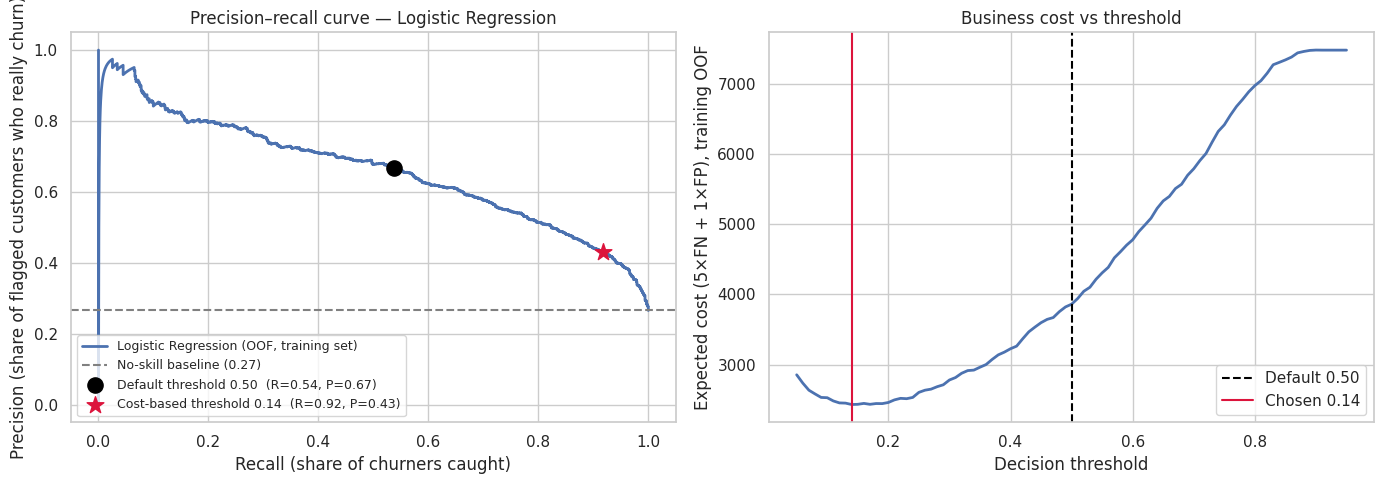

In [35]:
name = best_baseline_model
oof = oof_probs[name]
prec, rec, thr = precision_recall_curve(y_train, oof)

def pr_point(t):
    pred = (oof >= t).astype(int)
    return recall_score(y_train, pred), precision_score(y_train, pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rec, prec, lw=2, label=f"{name} (OOF, training set)")
axes[0].axhline(y_train.mean(), ls="--", color="grey", label=f"No-skill baseline ({y_train.mean():.2f})")
r05, p05 = pr_point(0.5)
rt, pt = pr_point(chosen_threshold[name])
axes[0].scatter(r05, p05, s=120, color="black", zorder=5, label=f"Default threshold 0.50  (R={r05:.2f}, P={p05:.2f})")
axes[0].scatter(rt, pt, s=160, color="crimson", marker="*", zorder=6,
                label=f"Cost-based threshold {chosen_threshold[name]:.2f}  (R={rt:.2f}, P={pt:.2f})")
axes[0].set_xlabel("Recall (share of churners caught)")
axes[0].set_ylabel("Precision (share of flagged customers who really churn)")
axes[0].set_title(f"Precision–recall curve — {name}")
axes[0].legend(loc="lower left", fontsize=9)

cost_curve = [business_cost(y_train.values, oof, t) for t in thresholds_grid]
axes[1].plot(thresholds_grid, cost_curve, lw=2)
axes[1].axvline(0.5, ls="--", color="black", label="Default 0.50")
axes[1].axvline(chosen_threshold[name], ls="-", color="crimson", label=f"Chosen {chosen_threshold[name]:.2f}")
axes[1].set_xlabel("Decision threshold")
axes[1].set_ylabel(f"Expected cost ({COST_FN}×FN + {COST_FP}×FP), training OOF")
axes[1].set_title("Business cost vs threshold")
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.5 Baseline vs each technique — comparison table

Every number below comes from the same held-out test set (1,409 customers, 374 churners). **Test cost** uses the same 5×FN + 1×FP rule, so the table also shows which approach would cost the business least.

In [36]:
imb_df = pd.DataFrame(imb_results)
imb_df["Test cost (5·FN + FP)"] = COST_FN * imb_df["FN (missed churners)"] + COST_FP * imb_df["FP (wasted offers)"]
imb_table = imb_df.set_index(["Model", "Technique"]).round(3)
imb_table

,,Threshold,Accuracy,Precision,Recall,F1,ROC AUC,FN (missed churners),FP (wasted offers),Test cost (5·FN + FP)
Model,Technique,,,,,,,,,
Logistic Regression,Baseline,0.50,0.800,0.655,0.519,0.579,0.843,180,102,1002
Random Forest,Baseline,0.50,0.789,0.630,0.492,0.553,0.826,190,108,1058
Gradient Boosting,Baseline,0.50,0.801,0.661,0.511,0.576,0.842,183,98,1013
Logistic Regression,Class weights,0.50,0.735,0.501,0.791,0.613,0.842,78,295,685
Random Forest,Class weights,0.50,0.786,0.621,0.495,0.551,0.826,189,113,1058
Gradient Boosting,Class weights,0.50,0.742,0.509,0.807,0.625,0.843,72,291,651
Logistic Regression,SMOTE,0.50,0.743,0.510,0.786,0.619,0.841,80,282,682
Random Forest,SMOTE,0.50,0.781,0.599,0.535,0.565,0.827,174,134,1004
Gradient Boosting,SMOTE,0.50,0.796,0.621,0.591,0.605,0.845,153,135,900


Change versus each model's own baseline (positive = improvement for recall/F1/AUC; negative = improvement for cost):

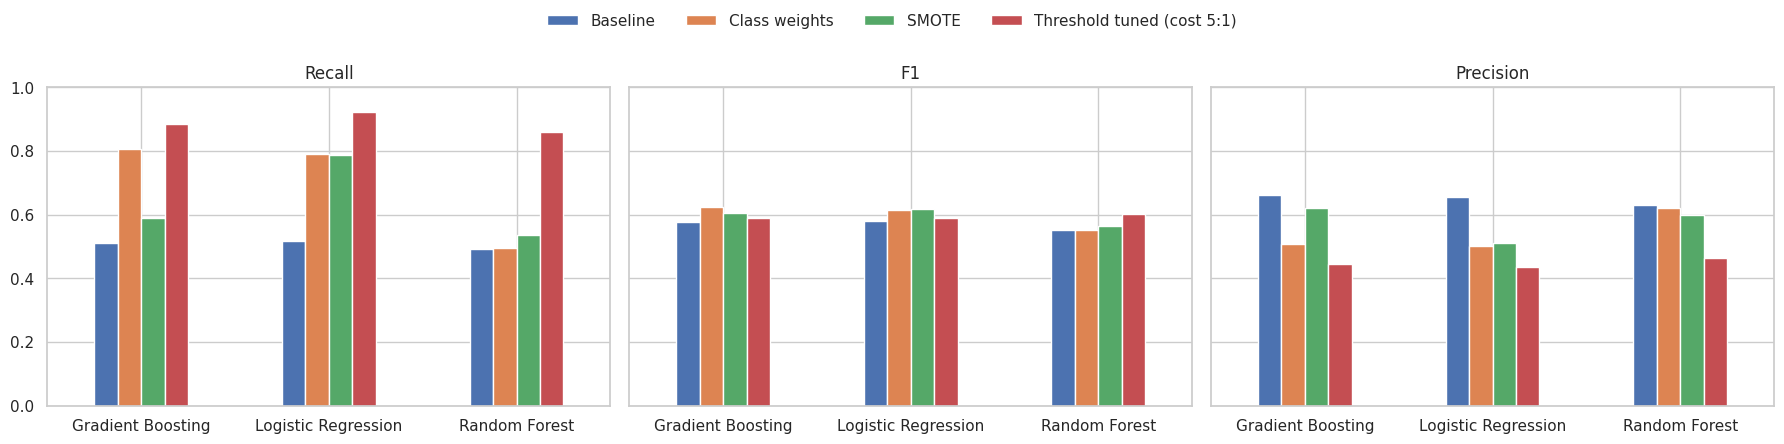

In [37]:
delta = []
for name in baseline_models:
    base = imb_df[(imb_df.Model == name) & (imb_df.Technique == "Baseline")].iloc[0]
    for _, row in imb_df[(imb_df.Model == name) & (imb_df.Technique != "Baseline")].iterrows():
        delta.append({
            "Model": name, "Technique": row.Technique,
            "Δ Recall": row.Recall - base.Recall,
            "Δ Precision": row.Precision - base.Precision,
            "Δ F1": row.F1 - base.F1,
            "Δ ROC AUC": row["ROC AUC"] - base["ROC AUC"],
            "Δ Test cost": row["Test cost (5·FN + FP)"] - base["Test cost (5·FN + FP)"],
        })
pd.DataFrame(delta).set_index(["Model", "Technique"]).round(3)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
order = ["Baseline", "Class weights", "SMOTE", f"Threshold tuned (cost {COST_FN}:{COST_FP})"]
for ax, metric in zip(axes, ["Recall", "F1", "Precision"]):
    pivot = imb_df.pivot(index="Model", columns="Technique", values=metric)[order]
    pivot.plot(kind="bar", ax=ax, rot=0, legend=False)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.set_xlabel("")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

Confusion matrices for the best baseline model, before and after each technique:

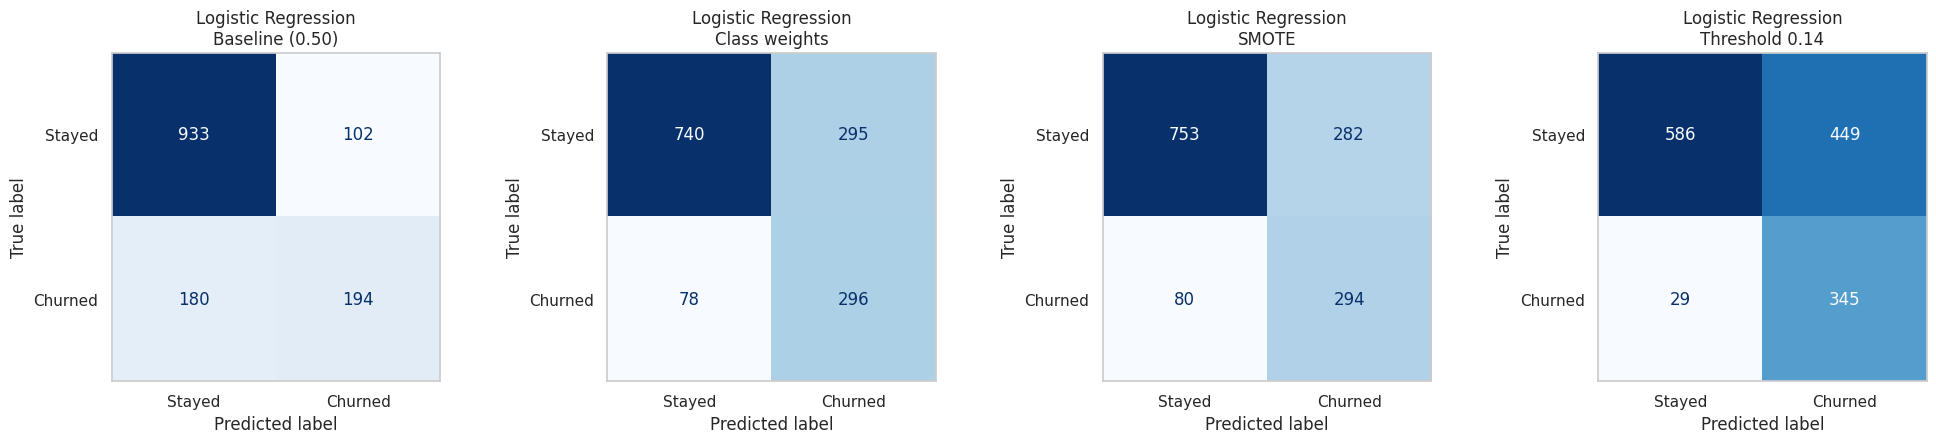

In [38]:
name = best_baseline_model
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
tech_preds = {
    "Baseline (0.50)": predictions[name],
    "Class weights": cw_models[name].predict(X_test_num),
    "SMOTE": smote_models[name].predict(X_test_num),
    f"Threshold {chosen_threshold[name]:.2f}": (baseline_probs[name] >= chosen_threshold[name]).astype(int),
}
for ax, (label, pred) in zip(axes, tech_preds.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Stayed", "Churned"],
                                            cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"{name}\n{label}")
    ax.grid(False)
plt.tight_layout()
plt.show()

### 5.6 What we learned from imbalance handling

**1. Our data is imbalanced, and the techniques confirm that it matters.** At the default 0.50 threshold, all three Part 4 baselines catch only about half of real churners (Logistic Regression recall = 0.519, which means 180 of the 374 test churners were missed). Every technique that shifts the balance towards the churn class raises recall sharply.

**2. Class weights and SMOTE give almost the same result for Logistic Regression.** Class weights raised LR recall from 0.519 to 0.791 and F1 from 0.579 to 0.613. SMOTE gave nearly the same thing (recall 0.786, F1 0.618). This is what we expected: both methods tell the model to treat the two classes as equally important. One reweights the existing churners and the other adds synthetic ones. The fractional dummy values that SMOTE creates did not visibly hurt.

**3. Random Forest barely reacted to class weights (F1 0.553 → 0.551).** Our forest grows each tree until its leaves are pure, so each leaf already predicts a single class. Reweighting changes which splits get chosen, but it hardly changes the final leaf votes, and it is those votes that the 0.50 cut-off is applied to. SMOTE helped RF a little (recall 0.532) because it changes the data the trees see. Threshold tuning helped RF the most (recall 0.861, F1 0.603), because it works directly on the vote share.

**4. ROC AUC did not move (0.826–0.845 in every row).** This is the most important finding in this section. None of these techniques made any model better at *ranking* churners above non-churners. They only moved *where on the curve* we operate. The model's ability to separate the classes comes from the features and the algorithm. Imbalance handling decides how that ability is spent: whether we trade precision for recall. That is why a business cost is needed to choose between them.

**5. Threshold tuning gives the lowest business cost, even though it does not give the highest F1.** Using the 5:1 cost, the threshold chosen on training data for Logistic Regression was **0.14**. On the test set it catches **345 of 374 churners (recall 0.922)** and misses only 29, against 180 missed at the baseline. The price is 449 unnecessary offers instead of 102 (precision falls to 0.435, so roughly 1 in 2.3 flagged customers is a real churner). The test cost falls from **1,002 to 594**, a 41% reduction and the lowest in the table. The best F1 comes from Gradient Boosting with class weights (0.625). F1 weighs false positives and false negatives about equally, while our business cost does not, so the model with the best F1 is not the one with the lowest cost.

**6. How sensitive the threshold is to our assumption.** The chosen threshold depends mostly on the cost ratio: about 0.24 at 3:1, 0.14 at 5:1 and 0.07 at 10:1. The cost curve is fairly flat between about 0.10 and 0.25, so small changes in the threshold cost little. The FN:FP ratio, however, is a business assumption that the retention team should confirm with real offer costs and customer lifetime values before deployment.

**Carried forward to Parts 6–7:** for the business goal of keeping churners at the lowest cost, the best configuration is **Logistic Regression with a cost-based threshold of 0.14** (test F1 = 0.591, ROC AUC = 0.843). It also beats the stratified dummy clearly on both required metrics (dummy F1 = 0.290, ROC AUC = 0.516). If the team would rather optimise F1, **Gradient Boosting with class weights** (F1 = 0.625, ROC AUC = 0.843) is the alternative. It is also a good sign that the simplest, most interpretable model came out on top.

In [39]:
# Carry the chosen configuration forward for Parts 6–7 and the submission summary
best_row = imb_df.loc[imb_df["Test cost (5·FN + FP)"].idxmin()]
print("Lowest business-cost configuration:", best_row.Model, "|", best_row.Technique)
print(f"  F1 = {best_row.F1:.3f}   ROC AUC = {best_row['ROC AUC']:.3f}   "
      f"Recall = {best_row.Recall:.3f}   Threshold = {best_row.Threshold}")
print(f"  Stratified dummy: F1 = {dummy_f1:.3f}   ROC AUC = {dummy_auc:.3f}")
print("  Beats dummy on F1:", best_row.F1 > dummy_f1, "| Beats dummy on ROC AUC:", best_row["ROC AUC"] > dummy_auc)

Lowest business-cost configuration: Logistic Regression | Threshold tuned (cost 5:1)
  F1 = 0.591   ROC AUC = 0.843   Recall = 0.922   Threshold = 0.14
  Stratified dummy: F1 = 0.290   ROC AUC = 0.516
  Beats dummy on F1: True | Beats dummy on ROC AUC: True


## Part 6. The Tie-In

### 6.1 Positive-class (churn) rate within each K-Means cluster

The three clusters from Part 3 were built purely from behavioural/demographic features (tenure, spend, add-ons, contract type, etc.) — `Churn` was never shown to `KMeans`. Here we bring the label back in after the fact and check whether the unsupervised groups line up with who actually churns.

In [40]:
cluster_summary = pd.DataFrame({
    "n_customers": df["cluster"].value_counts().sort_index()
})
cluster_summary["churn_rate"] = df.groupby("cluster")["Churn"].apply(lambda s: (s == "Yes").mean())
overall_churn_rate = (df["Churn"] == "Yes").mean()
cluster_summary["lift_vs_overall"] = (cluster_summary["churn_rate"] / overall_churn_rate).round(2)
cluster_summary["churn_rate"] = cluster_summary["churn_rate"].round(3)
cluster_summary["share_of_all_churners"] = (
    df[df["Churn"] == "Yes"]["cluster"].value_counts().sort_index() / (df["Churn"] == "Yes").sum()
).round(3)

print(f"Overall churn rate: {overall_churn_rate:.3f}")
cluster_summary


Overall churn rate: 0.265


,n_customers,churn_rate,lift_vs_overall,share_of_all_churners
cluster,,,,
0,1526,0.074,0.28,0.060
1,3258,0.421,1.59,0.734
2,2259,0.170,0.64,0.206


Visualizing the same numbers as a bar chart makes the size of the gap between clusters easier to read than the table alone.

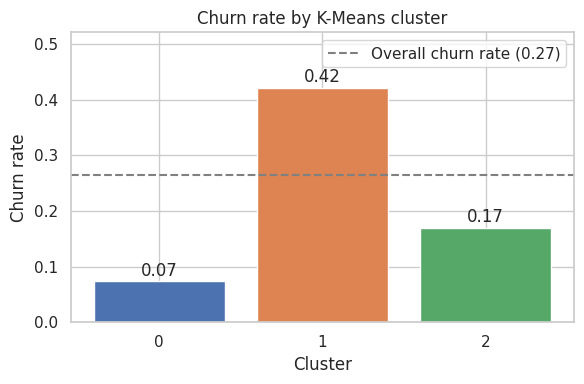

In [41]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(cluster_summary.index.astype(str), cluster_summary["churn_rate"], color=["#4C72B0", "#DD8452", "#55A868"])
ax.axhline(overall_churn_rate, ls="--", color="grey", label=f"Overall churn rate ({overall_churn_rate:.2f})")
for bar, rate in zip(bars, cluster_summary["churn_rate"]):
    ax.text(bar.get_x() + bar.get_width()/2, rate + 0.01, f"{rate:.2f}", ha="center")
ax.set_xlabel("Cluster")
ax.set_ylabel("Churn rate")
ax.set_title("Churn rate by K-Means cluster")
ax.set_ylim(0, max(cluster_summary["churn_rate"]) + 0.1)
ax.legend()
plt.tight_layout()
plt.show()


### 6.2 Were any clusters strong predictors of the label?

**Yes — cluster 1 is a clear standout.** With no `Churn` label ever shown to `KMeans`, the three clusters still split into very different risk bands:

| Cluster | Persona (Part 3.3) | Size | Churn rate | Lift vs. overall (26.5%) | Share of all churners |
|---|---|---|---|---|---|
| 0 | Long-tenure, bundled premium | 1,526 (22%) | 7.4% | 0.28× | 6.0% |
| 1 | New, mid-spend, high-risk | 3,258 (46%) | **42.1%** | **1.59×** | **73.4%** |
| 2 | Long-tenure, low-spend basics | 2,259 (32%) | 17.0% | 0.64× | 20.6% |

Cluster 1 alone — under half the customer base — accounts for nearly three-quarters of every churner in the dataset, at a rate 1.6× the overall average. Cluster 0 sits at the other extreme: a 7.4% churn rate, about a quarter of the overall rate, essentially the retained core of the business. Cluster 2 is closer to average but still meaningfully more loyal than cluster 1.

**What this tells us about the data.** Clustering was built purely from tenure, spend, add-ons, and contract mix — the same features Part 4's classifier leans on most heavily. The fact that an unsupervised method, with no access to the label, recovers almost the same risk grouping a supervised model would, tells us churn here is largely a function of **customer lifecycle stage** (new + month-to-month + few add-ons) rather than something subtle that only a label-aware model could uncover. That is reassuring for the classifier's feature choices, and it also means cluster membership itself is a cheap, explainable, model-free proxy the business can use whenever running the full classifier isn't practical — e.g. flagging "cluster 1" in a dashboard for a non-technical account manager.

## Part 7. Conclusion and Recommendations

**Which model would we deploy, and why?**
We would deploy **Logistic Regression with the cost-based threshold of 0.14** from Part 5 (`Threshold tuned (cost 5:1)`). Its ROC AUC (0.843) ties for the best of the three classifiers, but the deciding factor is the deployment goal: minimising the business cost of retention decisions, not maximising F1 in the abstract. At t = 0.14 it catches 92.2% of churners (missing 29 of 374) at the cost of 449 unnecessary offers, for a test-set cost of 594 — the lowest of all twelve model/technique combinations we tried, well below the untouched baseline's 1,002 and below every Random Forest or Gradient Boosting variant. Logistic Regression is also the simplest and most interpretable of the three, which matters for a model that will justify who gets a retention call: its coefficients tell a retention team directly why a customer was flagged, whereas Random Forest or Gradient Boosting would need a separate SHAP/importance step to explain the same decision.

**What would we do with another month?**
- Replace plain SMOTE with **SMOTENC**, which respects the one-hot categorical columns properly instead of interpolating fractional dummy values (flagged in 5.3; it didn't visibly hurt here, but it's worth confirming on a method built for this data).
- **Calibrate** the probabilities (Platt scaling or isotonic regression) before threshold tuning, since the whole cost-minimisation exercise assumes the predicted probabilities are meaningful, not just well-ranked.
- Get the **5:1 cost ratio validated by the retention/finance team** instead of assuming it from `MonthlyCharges`, then re-run the same threshold procedure — the sensitivity table in 5.4 shows the chosen threshold does move with the ratio.
- Add features the dataset doesn't have but the business likely does: support-ticket counts, complaint history, competitor promotions in the customer's area. Cluster 1's churn is concentrated among new, month-to-month, low-add-on customers, but *why* those specific customers churn within that group is still unexplained.
- Pilot the recommended threshold on a held-out slice of live traffic before a full rollout, and monitor for drift, since Telco pricing and competitor offers change over time.

**What did the clusters reveal that the classifier missed?**
The classifier outputs a probability per customer — accurate, but not a story anyone outside the team can act on directly. Clustering gave three named, describable personas, and in particular showed that risk is *concentrated*: cluster 1 is under half the customer base but holds 73% of all churners. A classifier's probability scores could in principle be binned to show something similar, but they wouldn't come with the same natural, feature-grounded persona ("new, mid-spend, few add-ons, month-to-month") that a non-technical stakeholder — marketing, retention ops — can act on without needing to interpret a model. The clustering is also a useful sanity check on the classifier: two independent methods, one supervised and one not, landing on the same underlying risk factors gives more confidence that those factors (tenure, contract, add-ons) are real drivers and not an artifact of how we trained the classifier.

**What was the hardest decision our team made?**
Choosing the 5:1 false-negative-to-false-positive cost ratio in Part 5. There was no ground-truth cost data available — we had to reason from `MonthlyCharges` and a rough multi-month revenue-loss argument, which is inherently a judgement call rather than something we could verify against the dataset. We handled this by stating the reasoning explicitly, treating 5:1 as a conservative middle estimate, and running a sensitivity check at 3:1 and 10:1 so the choice of threshold — and the model's recommended deployment — is transparent about how much it depends on that one assumption, rather than presenting a single number as if it were fact.

## Depth Track: Imbalance

**Track chosen: Imbalance.** Part 5 already applies all three required techniques (class weights, SMOTE, threshold tuning) to all three classifiers, so the depth-track work here builds directly on that instead of repeating it: we put every technique's precision-recall curve on one chart for the model we would actually ship, and then close with a single, explicit recommended operating point and the cost reasoning behind it.

### D.1 Precision–recall curves for all three techniques, one chart

All three curves below are for **Logistic Regression** (`best_baseline_model`), plotted on the held-out **test set** so the three techniques are compared on the same, untouched data. The star marks the business-cost threshold chosen in Part 5 (from training out-of-fold data only, then applied here).

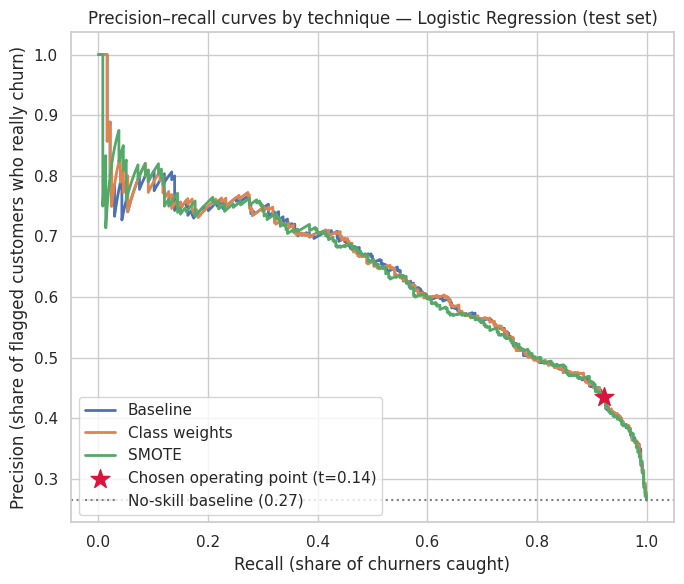

In [42]:
name = best_baseline_model

prob_variants = {
    "Baseline": baseline_probs[name],
    "Class weights": cw_models[name].predict_proba(X_test_num)[:, 1],
    "SMOTE": smote_models[name].predict_proba(X_test_num)[:, 1],
}

plt.figure(figsize=(7, 6))
for label, prob in prob_variants.items():
    prec, rec, _ = precision_recall_curve(y_test, prob)
    plt.plot(rec, prec, lw=2, label=label)

# the cost-based threshold chosen in Part 5, applied to the (unchanged) baseline probabilities
t = chosen_threshold[name]
pred_t = (baseline_probs[name] >= t).astype(int)
plt.scatter(recall_score(y_test, pred_t), precision_score(y_test, pred_t), s=200, marker="*",
            color="crimson", zorder=5, label=f"Chosen operating point (t={t:.2f})")

plt.axhline(overall_churn_rate if False else y_test.mean(), ls=":", color="grey",
            label=f"No-skill baseline ({y_test.mean():.2f})")
plt.xlabel("Recall (share of churners caught)")
plt.ylabel("Precision (share of flagged customers who really churn)")
plt.title(f"Precision–recall curves by technique — {name} (test set)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


### D.2 Recommended final operating point

Under the assumed cost of **5 units per missed churner vs. 1 unit per unnecessary retention offer**, the recommended operating point is **Logistic Regression at threshold 0.14** — the same configuration chosen in Part 5, now confirmed against every other technique's PR curve on the same test set rather than in isolation:

| Configuration | Precision | Recall | F1 | Test cost (5·FN + FP) |
|---|---|---|---|---|
| Baseline (t = 0.50) | 0.655 | 0.519 | 0.579 | 1,002 |
| Class weights (t = 0.50) | 0.501 | 0.791 | 0.613 | 685 |
| SMOTE (t = 0.50) | 0.510 | 0.786 | 0.619 | 682 |
| **Threshold tuned (t = 0.14)** | **0.435** | **0.922** | **0.591** | **594** |

The tuned threshold has a lower F1 than class weights or SMOTE — it trades away some precision (more unnecessary offers: 449 vs. ~285) to push recall up to 92.2% (missing only 29 of 374 churners, vs. ~80 for the other two techniques). Under our stated cost function that trade is worth making: each of those extra ~150–160 unnecessary offers costs 1 unit, while each additional churner caught saves 5. That is exactly why F1 alone is the wrong metric to deploy on here — it weights precision and recall equally, but our business cost does not.

**Caveat carried over from Part 5:** this recommendation is only as good as the 5:1 assumption. If the retention team's real offer cost or real customer lifetime value differs meaningfully from what we assumed, the threshold — and possibly which technique wins — should be re-derived from the sensitivity table in 5.4 rather than read off this one row.